EDA on customer satisfaction with:
1. Product category
2. Freight
3. Delivery

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/Othercomputers/My Laptop/NUS/IT5006 Fundamentals of Data Analytics/Group Project/smartcommerce_consolidated.csv')
customer_review = pd.read_csv('/content/drive/Othercomputers/My Laptop/NUS/IT5006 Fundamentals of Data Analytics/Group Project/Olist_CSV/olist_order_reviews_dataset.csv')


Check duplicates in consolidated dataset: a large proportion of order_id is duplicated.

In [ ]:
df['order_id'].duplicated().sum()

np.int64(13984)

Investigate into duplicate order_id: order_item_ids are different. Each order_id may contain one or more order items.

In [ ]:
order = df[df['order_id'].duplicated(keep=False)]['order_id'].iloc[0]
df[df['order_id'] == order].T

,13,14
order_id,0008288aa423d2a3f00fcb17cd7d8719,0008288aa423d2a3f00fcb17cd7d8719
order_item_id,1,2
product_id,368c6c730842d78016ad823897a372db,368c6c730842d78016ad823897a372db
seller_id,1f50f920176fa81dab994f9023523100,1f50f920176fa81dab994f9023523100
shipping_limit_date,2018-02-21 02:55:52,2018-02-21 02:55:52
price,49.9,49.9
freight_value,13.37,13.37
product_category_name_english,garden_tools,garden_tools
product_weight_g,1650.0,1650.0
customer_id,2355af7c75e7c98b43a87b2a7f210dc5,2355af7c75e7c98b43a87b2a7f210dc5


Aggregate by order_id. For product category, order items may come from different categories, collapse their category into "multi-category'.

In [ ]:
def collapse_category(x):
    unique_categories = x.dropna().unique()

    if len(unique_categories) == 1:
        return unique_categories[0]
    else:
        return 'multi-category'


df_order = df.groupby('order_id').agg({
    'price': 'sum',
    'freight_value': 'sum',
    'product_category_name_english': collapse_category,
    'delivery_days': 'first',
    'is_on_time': 'first'
}).reset_index()

df_order.head()

,order_id,price,freight_value,product_category_name_english,delivery_days,is_on_time
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,cool_stuff,7.0,True
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,pet_shop,16.0,True
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,furniture_decor,7.0,True
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,perfumery,6.0,True
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,garden_tools,25.0,True


Safety check: no duplicate order_id now

In [ ]:
df_order['order_id'].duplicated().sum()

np.int64(0)

Apply the same procedure for order review: duplicates found.

In [ ]:
customer_review['order_id'].duplicated().sum()

np.int64(551)

After investigation, some order_id have two review scores generated on differrent dates.

In [ ]:
dup_id = customer_review.loc[
    customer_review['order_id'].duplicated(),
    'order_id'
].iloc[4]

customer_review[
    customer_review['order_id'] == dup_id
]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
4753,3c95105686e2ae71e8fd94b6483eba79,f9c78e6e58306dc81efbbada1ac11f24,2,NaN,"comprei 4 cubas ao mesmo tempo, fui cobrada pe...",2017-09-19 00:00:00,2017-09-22 15:23:29
9795,95a3135743556b117d888cc8c6e12e11,f9c78e6e58306dc81efbbada1ac11f24,3,NaN,O produto chegou antes do prazo mas recebi um ...,2017-09-14 00:00:00,2017-09-17 11:14:08


Use the latest review score to conduct analytics.

In [ ]:
customer_review_latest = (
    customer_review
    .sort_values('review_answer_timestamp')
    .drop_duplicates(subset='order_id', keep='last')
)

Merging customer review with original dataset

In [ ]:
df_with_review = df_order.merge(customer_review[['order_id', 'review_score']], on='order_id', how='left')
df_with_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99214 entries, 0 to 99213
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99214 non-null  object 
 1   price                          99214 non-null  float64
 2   freight_value                  99214 non-null  float64
 3   product_category_name_english  99214 non-null  object 
 4   delivery_days                  97005 non-null  float64
 5   is_on_time                     99214 non-null  bool   
 6   review_score                   98465 non-null  float64
dtypes: bool(1), float64(4), object(2)
memory usage: 4.6+ MB


Check for NA values in feature "review_score"

In [ ]:
df_with_review['review_score'].isna().sum()

np.int64(749)

Drop those NA rows, then check the distribution of review scores 1 - 5.

In [ ]:
df_sat = df_with_review.dropna(subset=['review_score'])
df_sat['review_score'].value_counts().sort_index()

,count
review_score,
1.0,10884
2.0,3089
3.0,8126
4.0,19109
5.0,57257


Review score by product category. Filter out categories with sample size < 30.

In [ ]:
category_stats = (df_sat.groupby('product_category_name_english')['review_score'].agg(['count', 'mean']))
category_stats_filtered = category_stats[category_stats['count'] >= 30]
category_stats_filtered.sort_values('mean')

,count,mean
product_category_name_english,,
multi-category,789,3.068441
office_furniture,1253,3.632881
fashion_male_clothing,110,3.727273
fashio_female_clothing,40,3.775000
furniture_mattress_and_upholstery,38,3.815789
...,...,...
food_drink,223,4.385650
music,36,4.388889
books_technical,255,4.423529


<Axes: xlabel='mean', ylabel='product_category_name_english'>

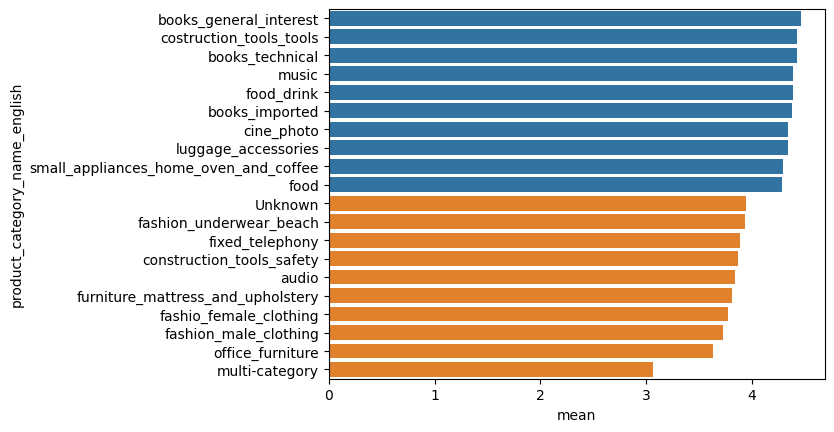

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
top_10_categories = category_stats_filtered.sort_values('mean', ascending=False).head(10)
bottom_10_categories = category_stats_filtered.sort_values('mean', ascending=False).tail(10)

sns.barplot(x=top_10_categories['mean'], y=top_10_categories.index)
sns.barplot(x=bottom_10_categories['mean'], y=bottom_10_categories.index)


Use boxplot to visualize the distribution of freight value by review score. The median freight value is similar across all review scores.

<Axes: xlabel='review_score', ylabel='freight_value'>

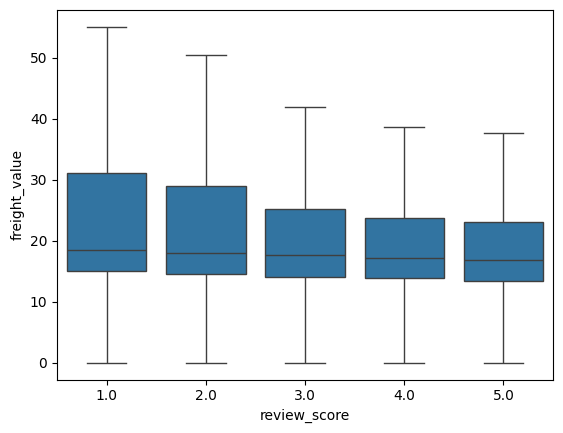

In [ ]:
sns.boxplot(
    data=df_sat,
    x='review_score',
    y='freight_value',
    showfliers=False
)

Use boxplot to visualize the distribution of freight value ratio (= freight value / price) by review score. Again, the median freight ratio is similar across all review scores.

/tmp/ipykernel_718/3102718374.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sat['freight_ratio'] = (


<Axes: xlabel='review_score', ylabel='freight_ratio'>

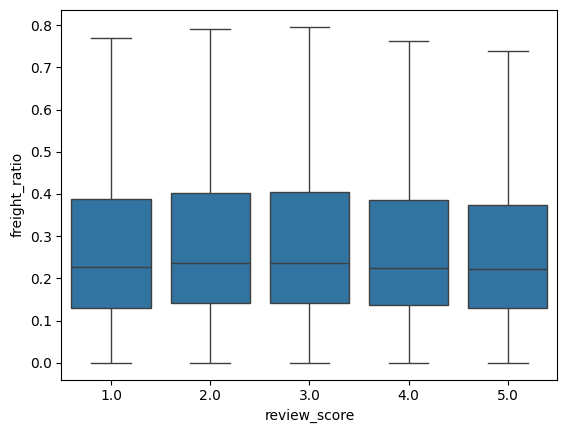

In [ ]:
df_sat['freight_ratio'] = (
    df_sat['freight_value'] / df_sat['price']
)

sns.boxplot(
    data=df_sat,
    x='review_score',
    y='freight_ratio',
    showfliers=False

)

Expore the other direction: compare the average review score of different freight_ratio bins. The median stays at 5 in every group but the mean gradually falls, the proportion of low scores increases.

In [ ]:
df_sat['freight_ratio_bin'] = pd.qcut(
    df_sat['freight_ratio'],
    q=5,
    duplicates='drop'
)

df_sat.groupby('freight_ratio_bin', observed=True)['review_score'].agg(
    ['count', 'mean', 'median']
)

/tmp/ipykernel_718/992103926.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sat['freight_ratio_bin'] = pd.qcut(


,count,mean,median
freight_ratio_bin,,,
"(-0.001, 0.115]",19713,4.136458,5.0
"(0.115, 0.183]",19674,4.124682,5.0
"(0.183, 0.273]",19692,4.117967,5.0
"(0.273, 0.435]",19693,4.078861,5.0
"(0.435, 21.447]",19693,4.065099,5.0


Then explore the proportion of low scores (1 to 2) for each freight_ratio bin. The proportion first decreases then increases (U-shape).

In [ ]:
df_sat['low_score'] = df_sat['review_score'] <= 2

df_sat.groupby('freight_ratio_bin', observed=True)['low_score'].mean()

/tmp/ipykernel_718/1859618182.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sat['low_score'] = df_sat['review_score'] <= 2


,low_score
freight_ratio_bin,
"(-0.001, 0.115]",0.141683
"(0.115, 0.183]",0.137288
"(0.183, 0.273]",0.135690
"(0.273, 0.435]",0.147921
"(0.435, 21.447]",0.146956


Use boxplot to visualize the distribution of delivery days by review score. The median delivery days decreases as review score increases.

<Axes: xlabel='review_score', ylabel='delivery_days'>

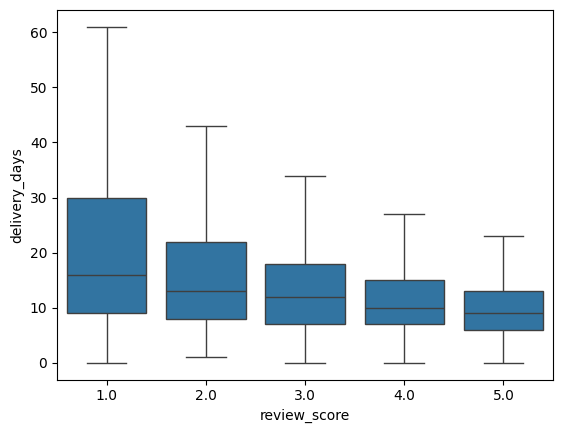

In [ ]:
sns.boxplot(
    data=df_sat,
    x='review_score',
    y='delivery_days',
    showfliers=False
)

Explore the other direction: compare the average review score of different delivery_days bins. Average review score decreases as delivery days increase.

In [ ]:
df_sat['delivery_days_bin'] = pd.qcut(
    df_sat['delivery_days'],
    q=5,
    duplicates='drop'
)

df_sat.groupby('delivery_days_bin', observed=True)['review_score'].agg(
    ['count', 'mean', 'median']
)

/tmp/ipykernel_718/1551627234.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sat['delivery_days_bin'] = pd.qcut(


,count,mean,median
delivery_days_bin,,,
"(-0.001, 6.0]",26039,4.417873,5.0
"(6.0, 8.0]",14402,4.365158,5.0
"(8.0, 12.0]",21424,4.291215,5.0
"(12.0, 17.0]",16388,4.190871,5.0
"(17.0, 208.0]",18106,3.419088,4.0


Compare mean and median review score between on time and late delivery. The mean and median have  large gaps.

In [ ]:
df_sat.groupby('is_on_time')['review_score'].agg(['count', 'mean', 'median'])

,count,mean,median
is_on_time,,,
False,9807,2.396350,1.0
True,88658,4.293578,5.0
